# Part1

## setup

In [3]:
"""
หากยังไม่มี library ใด ให้ติดตั้งก่อน
!pip install -q nltk wordcloud scikit-learn pandas matplotlib tqdm huggingface_hub
!pip install -q pythainlp          # ใช้เมื่อทำงานกับข้อความภาษาไทย
"""
import json, os, re, random, itertools, time
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

import nltk
for pkg in ["punkt_tab", "stopwords", "wordnet", "vader_lexicon"]:
    nltk.download(pkg, quiet=True)

%matplotlib inline

RANDOM_SEED = 42
SAMPLE_N = 20_000         # เวอร์ชันลด workload: Part 2 ใช้อย่างน้อย 20,000 รีวิว
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

DATA_DIR = "./data/"
os.makedirs(DATA_DIR, exist_ok=True)

w:\Learn_Program\project_bigdata\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ดึงข้อมูลจาก Hugging Face

In [4]:

# -----------------------------
# Dataset
# -----------------------------
REPO_ID = "alpindale/two-million-bluesky-posts"

# ใช้เพียง 1 ไฟล์ก่อน
FILENAME = "posts_20241127_075630.jsonl"

DATA_DIR = "./data/bluesky"
os.makedirs(DATA_DIR, exist_ok=True)


# -----------------------------
# Download
# -----------------------------
file_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=FILENAME,
    repo_type="dataset",
    local_dir=DATA_DIR
)

print("Downloaded file:")
print(file_path)

Downloaded file:
W:\Learn_Program\project_bigdata\Part_1\data\bluesky\posts_20241127_075630.jsonl


In [5]:
# ============================================================
# Cell 2 — Read JSONL
# ============================================================

def iter_jsonl(path):
    """
    อ่าน JSONL ทีละบรรทัด
    """
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if not line:
                continue

            try:
                yield json.loads(line)
            except json.JSONDecodeError:
                continue


# อ่านข้อมูล
rows = list(iter_jsonl(file_path))

print("จำนวนโพสต์:", len(rows))

# แปลงเป็น DataFrame
df = pd.DataFrame(rows)

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nตัวอย่างข้อมูล:")
display(df.head())

จำนวนโพสต์: 100000

Columns:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']

Shape:
(100000, 6)

ตัวอย่างข้อมูล:


,text,created_at,author,uri,has_images,reply_to
0,기사로서의 실력은 타의 추종을 불허하지만 일상생활토크는 영 어색한 둠쪼롱과 적당히 ...,2024-11-27T07:56:28.535Z,did:plc:z3dbv7bbotsaxzdmmlwoypha,at://did:plc:z3dbv7bbotsaxzdmmlwoypha/app.bsky...,False,NaN
1,Lovely stuff.,2024-11-27T07:56:28.717Z,did:plc:4dn3nlaku6z3ltxzkxglyqdq,at://did:plc:4dn3nlaku6z3ltxzkxglyqdq/app.bsky...,False,at://did:plc:y7vhfdg5iq7qbotunr767enp/app.bsky...
2,눈이 와방 내려서 무거워진 나무에 햇빛이 쨍하게 드니까 예쁘다,2024-11-27T07:56:21.343Z,did:plc:fn4xjeryjchlrtjwippuumxm,at://did:plc:fn4xjeryjchlrtjwippuumxm/app.bsky...,True,NaN
3,範の字が使用されているあたり3級以上なんだろうけど、時事を扱った問題も出すんだね。,2024-11-27T07:56:28.499Z,did:plc:aaf7jrpncnzlbiqfzkgugowq,at://did:plc:aaf7jrpncnzlbiqfzkgugowq/app.bsky...,False,NaN
4,WoAH,2024-11-27T07:56:29.868Z,did:plc:l6fvehl7vj44d44aydnds7qr,at://did:plc:l6fvehl7vj44d44aydnds7qr/app.bsky...,False,at://did:plc:54ordrb4cjngwlivuadayono/app.bsky...


## Q1

In [7]:
# ============================================================
# Q1 — When do people post?
# ============================================================

# แปลง created_at เป็น datetime
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce",
    utc=True
)

# ตัดแถวที่ไม่มีเวลา
time_df = df.dropna(subset=["created_at"]).copy()

# จำนวนโพสต์
n_posts = len(df)

# ช่วงเวลา
start_time = time_df["created_at"].min()
end_time = time_df["created_at"].max()

# ชั่วโมง
time_df["hour"] = time_df["created_at"].dt.hour

hour_counts = (
    time_df["hour"]
    .value_counts()
    .sort_index()
)

peak_hour = hour_counts.idxmax()
peak_count = hour_counts.max()

print("========== Q1: Posting Time ==========")
print(f"จำนวนโพสต์ทั้งหมด: {n_posts:,}")
print(f"ข้อมูลเริ่มต้น: {start_time}")
print(f"ข้อมูลสิ้นสุด: {end_time}")
print(f"ชั่วโมงที่มีโพสต์มากที่สุด: {peak_hour:02d}:00 UTC")
print(f"จำนวนโพสต์ในชั่วโมงนั้น: {peak_count:,}")

========== Q1: Posting Time ==========
จำนวนโพสต์ทั้งหมด: 100,000
ข้อมูลเริ่มต้น: 2012-10-25 08:22:45+00:00
ข้อมูลสิ้นสุด: 2024-11-30 10:50:04.343000+00:00
ชั่วโมงที่มีโพสต์มากที่สุด: 08:00 UTC
จำนวนโพสต์ในชั่วโมงนั้น: 79,035


## Q2

In [8]:
# ============================================================
# Q2 — Languages
# ============================================================

print("Columns:")
print(df.columns.tolist())

if "predicted_language" in df.columns:

    lang_counts = (
        df["predicted_language"]
        .fillna("unknown")
        .value_counts()
    )

    lang_percent = (
        lang_counts / len(df) * 100
    ).round(2)

    language_table = pd.DataFrame({
        "posts": lang_counts,
        "percentage": lang_percent
    })

    display(language_table.head(10))

else:
    print("ไม่พบ predicted_language")
    print("ไฟล์นี้เป็น default configuration")
    print("ให้เปลี่ยนไปใช้ไฟล์/configuration ที่มี language predictions")

Columns:
['text', 'created_at', 'author', 'uri', 'has_images', 'reply_to']
ไม่พบ predicted_language
ไฟล์นี้เป็น default configuration
ให้เปลี่ยนไปใช้ไฟล์/configuration ที่มี language predictions


## Q3

In [9]:
# ============================================================
# Q3 — What are people talking about?
# ============================================================

texts = (
    df["text"]
    .fillna("")
    .astype(str)
)

# -----------------------------
# Hashtag
# -----------------------------
hashtags = []

for text in texts:
    tags = re.findall(r"#\w+", text.lower())
    hashtags.extend(tags)

hashtag_counts = Counter(hashtags)

hashtag_table = pd.DataFrame(
    hashtag_counts.most_common(20),
    columns=["hashtag", "count"]
)

print("========== Top Hashtags ==========")
display(hashtag_table)

========== Top Hashtags ==========


,hashtag,count
0,#art,261
1,#nsfw,175
2,#booksky,142
3,#innovation,137
4,#photography,122
5,#nowplaying,108
6,#books,103
7,#bookchallenge,87
8,#bluesky,81
9,#ai,77


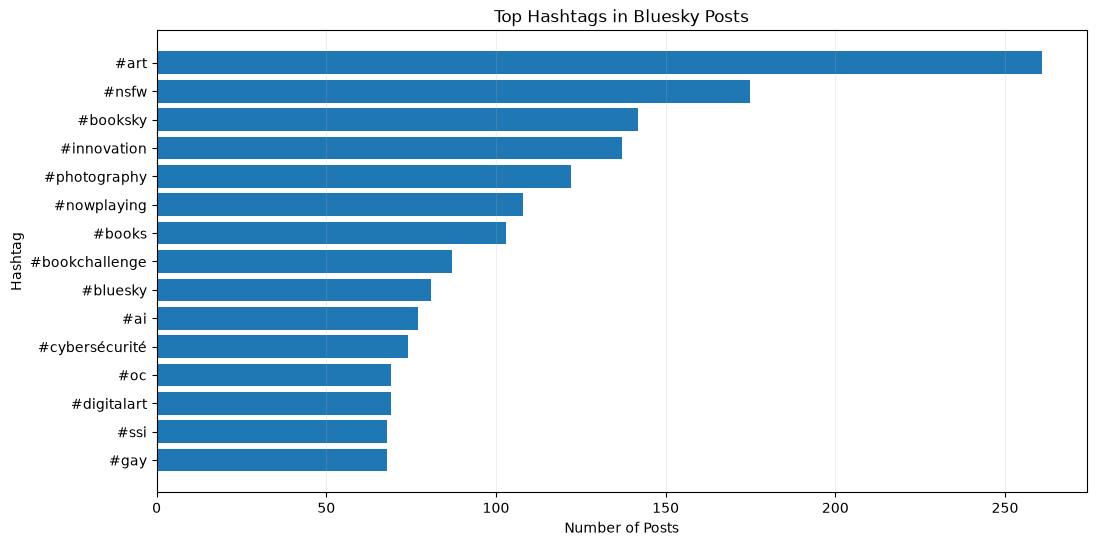

In [11]:
plt.figure(figsize=(12, 6))

top_tags = hashtag_table.head(15).sort_values("count")

plt.barh(
    top_tags["hashtag"],
    top_tags["count"]
)

plt.xlabel("Number of Posts")
plt.ylabel("Hashtag")
plt.title("Top Hashtags in Bluesky Posts")

plt.grid(axis="x", alpha=0.2)

plt.show()

## Q4

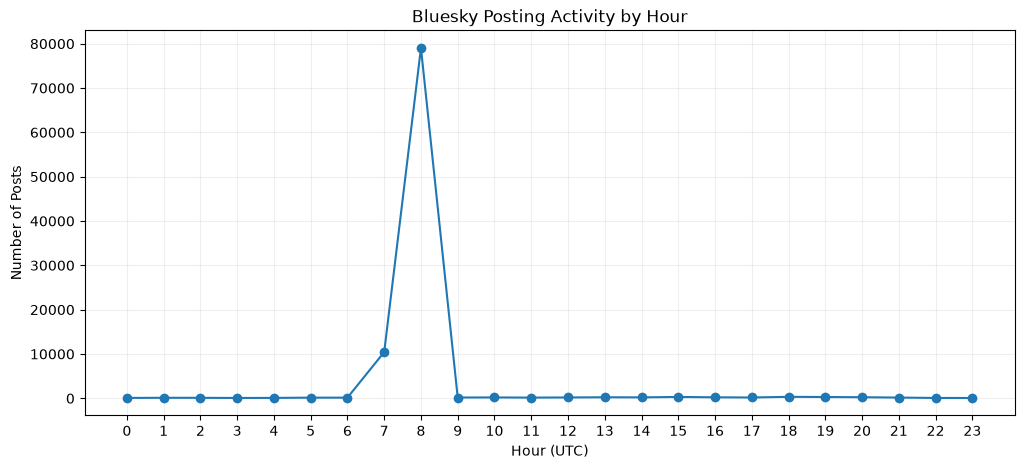

In [10]:
# ============================================================
# Q4 — Visualization
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    hour_counts.index,
    hour_counts.values,
    marker="o"
)

plt.xlabel("Hour (UTC)")
plt.ylabel("Number of Posts")
plt.title("Bluesky Posting Activity by Hour")

plt.xticks(range(24))
plt.grid(alpha=0.2)

plt.show()
